# Bluesky: social posts - Lane A (the real experience: you prompt, the agent builds)

**SISMID 2026 - Day 2, 11:00.** X/Twitter and Facebook post access are closed (paid API
since 2023; CrowdTangle shut down 2024). **Bluesky is open**, except full-text search
needs auth, so we monitor *accounts* instead. You drive a coding agent (Codex, Claude
Code, or Antigravity CLI).


## About this data source

**Bluesky.** A public social network with an *open door*: anyone can read public posts
without an account, which is exactly what Twitter stopped allowing. Think of it as:
*"a Twitter-shaped network you are still allowed to read."*

- **Explore it in a browser:** <https://bsky.app/> (search *dengue* or *outbreak* in the
  site's own search box, then open a public-health account and scroll its feed, which is
  exactly what this notebook reads)

**The catch:** keyword search through the API needs a login, but *finding accounts* and
*reading their public posts* do not. So we watch **accounts**, not keywords.

> **What happened to the classics:** X/Twitter went paid-API in 2023; Facebook's CrowdTangle
> shut down in 2024 (research access by application only). Our own COVID exercise file still
> has Twitter, Kinsa and Cuebiq columns, and all three of those streams are now closed.
> Novel data streams are fragile.


## Step 1: discover public-health accounts

> *Using the public Bluesky AppView (https://public.api.bsky.app/xrpc, no auth), call*
> *app.bsky.actor.searchActors for terms like 'epidemiology', 'public health',*
> *'outbreak', 'infectious disease'. Build a watch list of handles + display names.*


In [1]:
# Agent's account discovery:
import json
import os
import time
import urllib.parse
import urllib.request

import pandas as pd

api = 'https://public.api.bsky.app/xrpc'
watch_terms = ['epidemiology', 'public health', 'outbreak', 'infectious disease']

def bsky(method, **params):
    request = urllib.request.Request(
        f'{api}/{method}?{urllib.parse.urlencode(params)}',
        headers={'User-Agent': 'SISMID2026-course/1.0'},
    )
    with urllib.request.urlopen(request, timeout=30) as response:
        return json.loads(response.read())

try:
    accounts = {}
    for term in watch_terms:
        for actor in bsky('app.bsky.actor.searchActors', q=term, limit=10).get('actors', []):
            accounts[actor['handle']] = actor.get('displayName') or ''
        time.sleep(0.25)
    watchlist = pd.DataFrame(accounts.items(), columns=['handle', 'display_name'])
    if watchlist.empty:
        raise RuntimeError('no accounts returned')
except Exception as error:
    cache = '../data/bluesky_health_accounts.csv' if os.path.exists('../data/bluesky_health_accounts.csv') else 'data/bluesky_health_accounts.csv'
    watchlist = pd.read_csv(cache)
    print(f'Live discovery failed: {error}; using {cache}')

print(f'{len(watchlist)} accounts on the watch list')
watchlist.head(10)


40 accounts on the watch list


,handle,display_name
0,epidemiology.bsky.social,Epidemiology!
1,jclinepi.bsky.social,Journal of Clinical Epidemiology
2,amjepi.bsky.social,American Journal of Epidemiology
3,harvardepi.bsky.social,Harvard Epidemiology
4,imsepidemiology.bsky.social,"IMS Epidemiology, University of Cambridge"
5,ises-epi.bsky.social,International Social Epidemiology Society
6,mirandapharmdmph.bsky.social,Miranda So PharmD MPH (Epidemiology)
7,sheaepi.bsky.social,Society for Healthcare Epidemiology of America...
8,ichejournal.bsky.social,Infection Control & Hospital Epidemiology
9,ocbe.bsky.social,Oslo Centre for Biostatistics and Epidemiology


## Step 2: scan their public feeds

> *For each account call app.bsky.feed.getAuthorFeed (no auth) and pull recent posts.*
> *Flag posts mentioning disease keywords (dengue, influenza, covid, measles, rsv,*
> *outbreak, h5n1, malaria, mpox). Return a tidy table: date, handle, keywords, text.*
> *Use a WORD-BOUNDARY regex, not a substring test.*


In [2]:
# Agent's feed scan:
import re

keywords = ['dengue', 'influenza', 'covid', 'measles', 'rsv', 'outbreak', 'h5n1',
            'malaria', 'cholera', 'mpox', 'avian flu', 'bird flu', 'flu']
keyword_pattern = re.compile(r'\b(' + '|'.join(re.escape(word) for word in keywords) + r')\b', re.I)

try:
    rows = []
    scanned = 0
    for handle in watchlist['handle'].head(25):
        feed = bsky('app.bsky.feed.getAuthorFeed', actor=handle, limit=50).get('feed', [])
        for item in feed:
            record = item.get('post', {}).get('record', {})
            text = (record.get('text') or '').replace('\n', ' ').strip()
            scanned += 1
            matches = sorted({word.lower() for word in keyword_pattern.findall(text)})
            if matches:
                rows.append({'date': (record.get('createdAt') or '')[:10], 'handle': handle,
                             'keywords': ';'.join(matches), 'text': text[:280]})
        time.sleep(0.15)
    posts = pd.DataFrame(rows)
    if posts.empty:
        raise RuntimeError('no keyword matches returned')
    print(f'scanned {scanned} posts -> {len(posts)} outbreak-keyword posts')
except Exception as error:
    cache = '../data/bluesky_health_posts.csv' if os.path.exists('../data/bluesky_health_posts.csv') else 'data/bluesky_health_posts.csv'
    posts = pd.read_csv(cache)
    print(f'Live feed scan failed: {error}; using {cache}')

posts.head()


scanned 1131 posts -> 100 outbreak-keyword posts


,date,handle,keywords,text
0,2026-06-13,jclinepi.bsky.social,covid,A Systematic Review of Observational Studies o...
1,2026-05-07,harvardepi.bsky.social,covid;influenza,Join us on TODAY 5/7 at 1PM ET with Nick Reich...
2,2026-06-02,sheaepi.bsky.social,outbreak,"🧵3/4: Without full participation in WHO, the U..."
3,2026-06-02,sheaepi.bsky.social,outbreak,🧵1/4: The United States is at a critical momen...
4,2026-05-29,ichejournal.bsky.social,outbreak,New in ICHE: Ralstonia pickettii outbreak in p...


## Step 3: prove the word-boundary point

> *Show me the difference: count posts matching the substring 'flu' anywhere versus the*
> *word-boundary pattern \bflu\b, and print an example the substring version wrongly*
> *catches.*

**Why:** naive substring matching flags **"influence"** as flu. The pipeline runs fine
and returns confident nonsense. This is the verify habit in one bug.


In [3]:
# Agent's false-positive comparison:
substring_flu = posts['text'].str.contains('flu', case=False, na=False).sum()
word_flu = posts['text'].str.contains(r'\bflu\b', case=False, na=False, regex=True).sum()

print(f"substring 'flu' anywhere: {substring_flu}")
print(f"word-boundary \bflu\b:     {word_flu}")
false_positives = posts.loc[
    posts['text'].str.contains('flu', case=False, na=False)
    & ~posts['text'].str.contains(r'\bflu\b', case=False, na=False, regex=True),
    ['handle', 'text'],
]
print('\nSubstring matching also catches words such as influenza and influencing:')
false_positives.head(3)


substring 'flu' anywhere: 21
word-boundary flu:     18

Substring matching also catches words such as influenza and influencing:


,handle,text
1,harvardepi.bsky.social,Join us on TODAY 5/7 at 1PM ET with Nick Reich...
63,pandemiccenter.bsky.social,Understanding how climate drives influenza can...
72,pandemiccenter.bsky.social,New paper from my group led by PhD student Ale...


## Step 4: summarise and save

> *Tally the keywords and plot them, print the five most recent outbreak posts, and save*
> *a tidy CSV.*


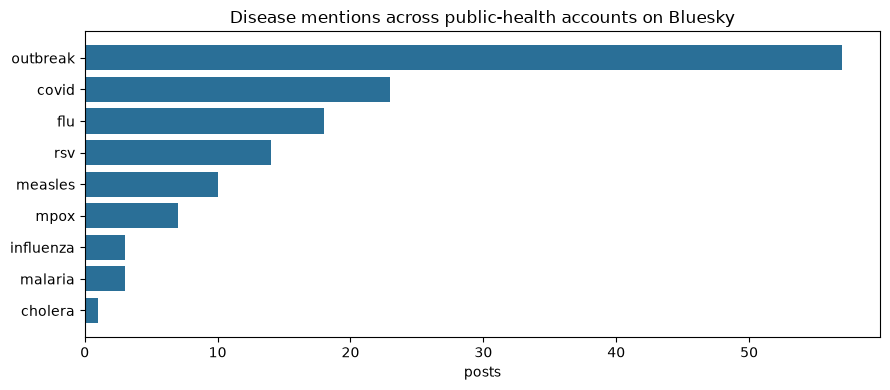

Five most recent outbreak-keyword posts:
- [2026-07-21] @pandemiccenter.bsky.social (measles) #Measles, #Ebola, and #Cyclosporiasis! infectious disease threats are constantly evolving across the
- [2026-07-20] @publichealth.boston.gov (covid;flu;rsv) Wastewater data for July 20 is now available:   • Citywide COVID-19 level: Very Low   • Citywide flu
- [2026-07-20] @yalesph.bsky.social (outbreak) Dean @meganranney.bsky.social joined CNN yesterday to discuss the current cyclosporiasis outbreak an
- [2026-07-20] @firedbutfighting.bsky.social (outbreak) Well, our feed is back to its regularly scheduled 💩.   Culturing cyclospora on produce is very diffi
- [2026-07-19] @firedbutfighting.bsky.social (outbreak) Dr Elizabeth about Americans in quarantine due to Ebola outbreak in DRC.  NY Times: "About a dozen A

saved 100 posts to ../data/bluesky_outbreak_chatter.csv


In [4]:
# Agent's tally + save:
import matplotlib.pyplot as plt
from pathlib import Path

keyword_counts = posts['keywords'].str.split(';').explode().value_counts()
plt.figure(figsize=(9, 4))
plt.barh(keyword_counts.index[::-1], keyword_counts.values[::-1], color='#2A6F97')
plt.xlabel('posts')
plt.title('Disease mentions across public-health accounts on Bluesky')
plt.tight_layout()
plt.show()

print('Five most recent outbreak-keyword posts:')
for _, post in posts.sort_values('date', ascending=False).head(5).iterrows():
    print(f"- [{post['date']}] @{post['handle']} ({post['keywords']}) {post['text'][:100]}")

output_dir = Path('../data') if Path('../data').is_dir() else Path('data')
output_path = output_dir / 'bluesky_outbreak_chatter.csv'
posts.to_csv(output_path, index=False)
print(f'\nsaved {len(posts)} posts to {output_path}')


## Reflection

- Account monitoring, not surveillance: small community, real selection bias.
- **Streams are fragile:** `covid_traces_WA.csv` still has Twitter, Kinsa and Cuebiq
  columns, and all three of those sources are now closed.
